In [ ]:
import pandas as pd
import plotly.express as px
import os

# Load data
nav = pd.read_csv("../data/processed/02_nav_history_cleaned.csv")

# Convert date column
nav["date"] = pd.to_datetime(nav["date"])

# Check number of schemes
print("Number of Funds:", nav["amfi_code"].nunique())

# Create NAV trend chart
fig = px.line(
    nav,
    x="date",
    y="nav",
    color="amfi_code",
    title="Daily NAV Trend for All 40 Mutual Fund Schemes (2022-2026)",
    labels={
        "date": "Date",
        "nav": "NAV",
        "amfi_code": "AMFI Code"
    }
)

# Highlight 2023 Bull Run
fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    annotation_text="2023 Bull Run",
    annotation_position="top left",
    opacity=0.2
)

# Highlight 2024 Market Correction
fig.add_vrect(
    x0="2024-01-01",
    x1="2024-06-30",
    annotation_text="2024 Market Correction",
    annotation_position="top right",
    opacity=0.2
)

# Show chart
fig.show()

# Create charts folder if not exists
os.makedirs("../reports/charts", exist_ok=True)
                                                
# Save interactive chart
fig.write_html("../reports/charts/nav_trend.html")

print("Chart saved successfully!")

Number of Funds: 40


Chart saved successfully!


In [19]:
import pandas as pd
import plotly.express as px
import os

# Load SIP data
sip = pd.read_csv("../data/raw/04_monthly_sip_inflows.csv")

# Convert month column
sip["month"] = pd.to_datetime(sip["month"])

# Create line chart
fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    markers=True,
    title="Monthly SIP Inflows (Jan 2022 - Dec 2025)",
    labels={
        "month": "Month",
        "sip_inflow_crore": "SIP Inflow (₹ Crore)"
    }
)

# Highlight Dec 2025 peak
fig.add_annotation(
    x="2025-12-01",
    y=31002,
    text="All-Time High ₹31,002 Cr",
    showarrow=True
)

fig.show()

# Save chart
os.makedirs("../reports/charts", exist_ok=True)
fig.write_html("../reports/charts/sip_trend.html")

print("SIP Trend Chart Saved Successfully!")

SIP Trend Chart Saved Successfully!


## Insight 2: SIP Inflow Trend

Monthly SIP inflows increased steadily between 2022 and 2025, indicating growing investor confidence in mutual funds. The highest SIP inflow of ₹31,002 Crore was recorded in December 2025.

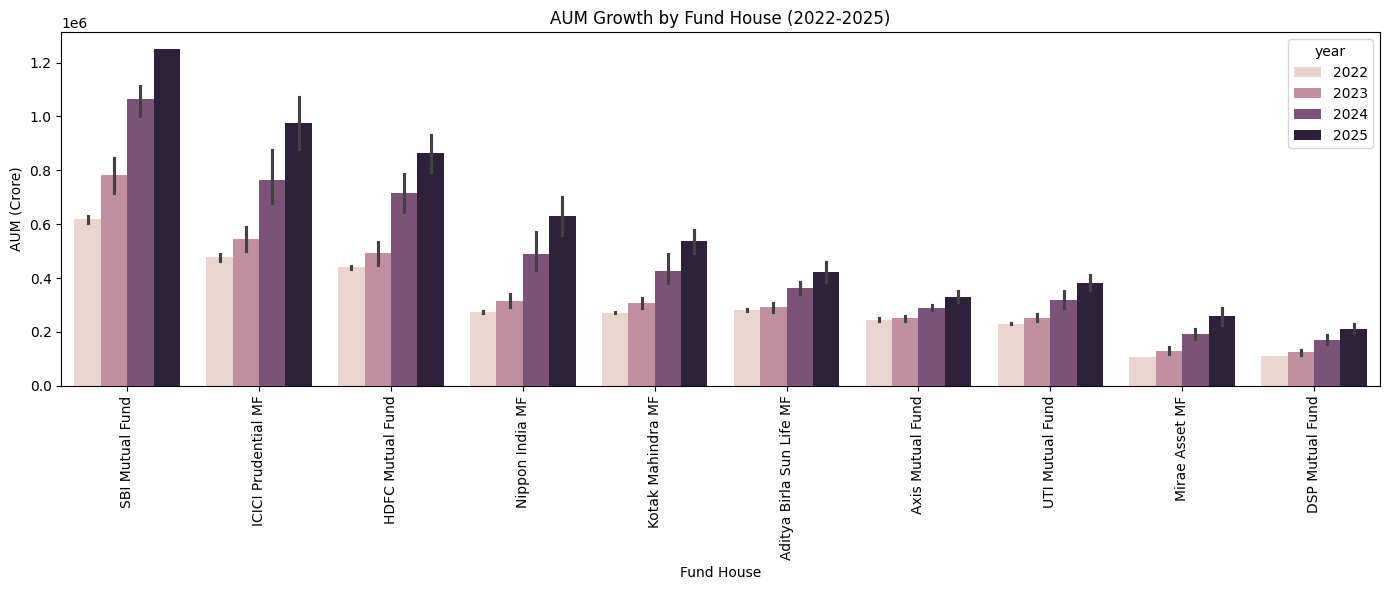

Chart saved successfully


In [20]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

# Load data
aum = pd.read_csv("../data/raw/03_aum_by_fund_house.csv")

# Convert date to datetime
aum["date"] = pd.to_datetime(aum["date"])

# Extract year
aum["year"] = aum["date"].dt.year

# Plot
plt.figure(figsize=(14,6))

sns.barplot(
    data=aum,
    x="fund_house",
    y="aum_crore",
    hue="year"
)

plt.title("AUM Growth by Fund House (2022-2025)")
plt.xlabel("Fund House")
plt.ylabel("AUM (Crore)")
plt.xticks(rotation=90)

plt.tight_layout()

# Save chart
os.makedirs("../reports/charts", exist_ok=True)
plt.savefig("../reports/charts/aum_growth.png")

plt.show()

print("Chart saved successfully")

## Insight 3: AUM Growth Analysis

SBI Mutual Fund maintained the highest Assets Under Management (AUM) among major fund houses during the analysis period. Large fund houses consistently expanded their AUM, reflecting increasing investor participation in mutual funds.

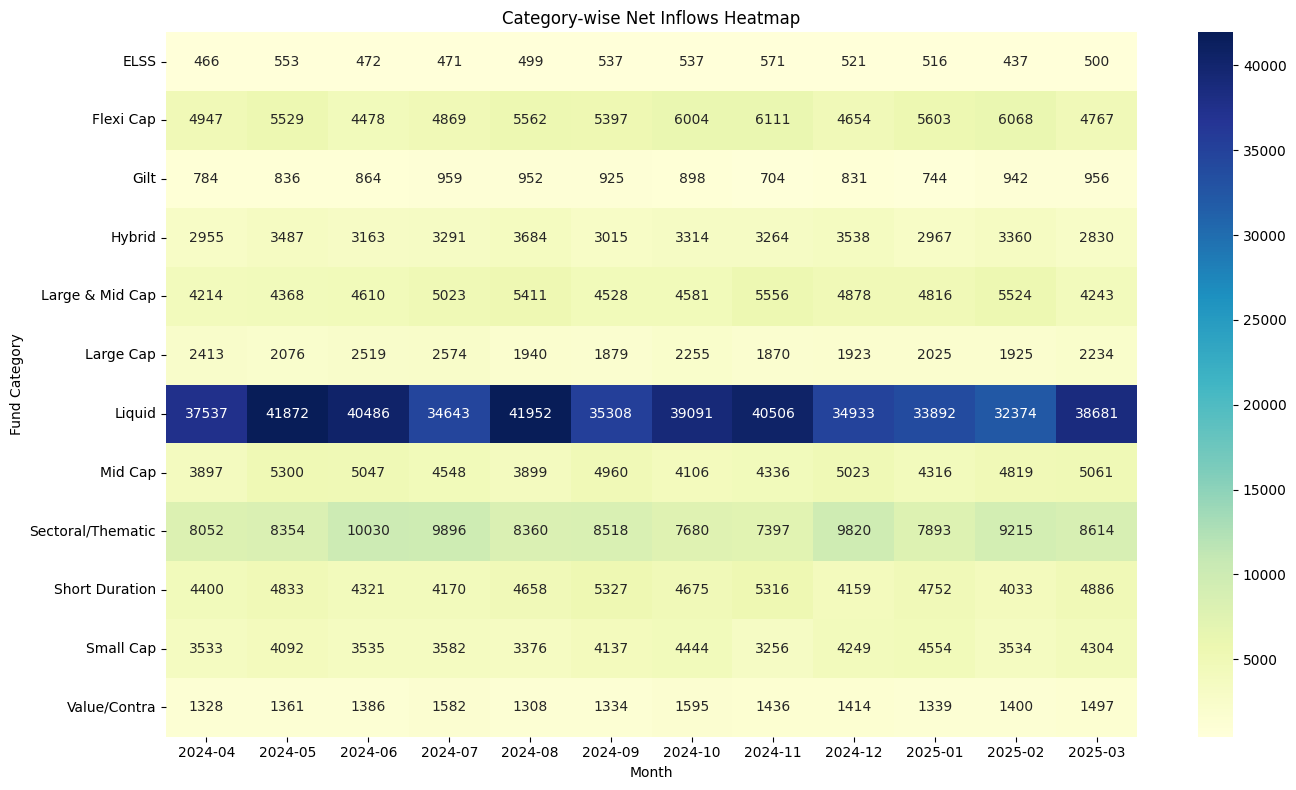

Chart saved successfully


In [21]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

# Load data
category = pd.read_csv("../data/raw/05_category_inflows.csv")

# Create pivot table
heatmap_data = category.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

# Plot heatmap
plt.figure(figsize=(14,8))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu"
)

plt.title("Category-wise Net Inflows Heatmap")
plt.xlabel("Month")
plt.ylabel("Fund Category")

plt.tight_layout()

# Save chart
os.makedirs("../reports/charts", exist_ok=True)
plt.savefig("../reports/charts/category_heatmap.png")

plt.show()

print("Chart saved successfully")

## Insight 4: Category Inflow Analysis

Flexi Cap, Mid Cap, and Small Cap funds attracted strong investor inflows across multiple months. Certain categories consistently received higher investments, indicating investor preference toward growth-oriented equity funds.

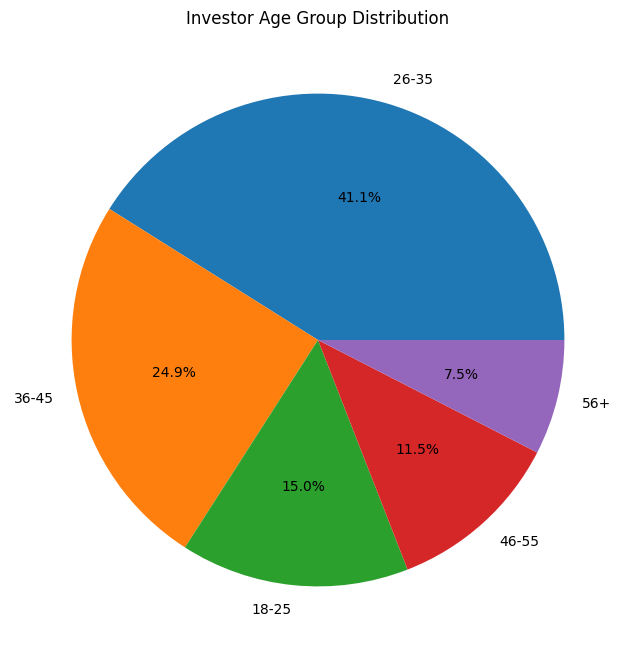

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import os

df = pd.read_csv("../data/processed/08_investor_transactions_cleaned.csv")

plt.figure(figsize=(8,8))

df["age_group"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Investor Age Group Distribution")
plt.ylabel("")

os.makedirs("../reports/charts", exist_ok=True)
plt.savefig("../reports/charts/age_group_distribution.png")

plt.show()

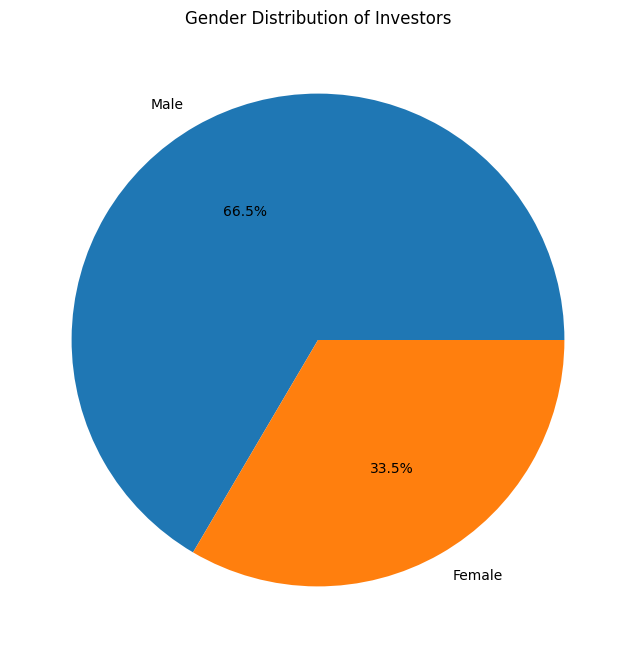

In [23]:
plt.figure(figsize=(8,8))

df["gender"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Gender Distribution of Investors")
plt.ylabel("")

plt.savefig("../reports/charts/gender_distribution.png")

plt.show()

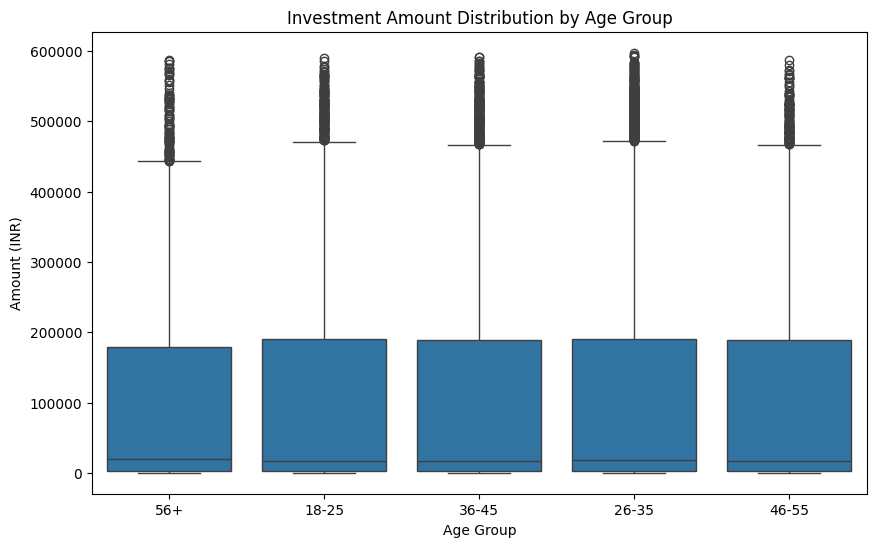

In [24]:
import seaborn as sns

plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="age_group",
    y="amount_inr"
)

plt.title("Investment Amount Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Amount (INR)")

plt.savefig("../reports/charts/amount_by_age_group.png")

plt.show()

## Insight 5: Investor Demographics

The majority of investors belong to the working-age population. Investment behaviour varies across age groups, with some age categories showing higher median investment amounts. Gender participation appears relatively balanced across the investor base.

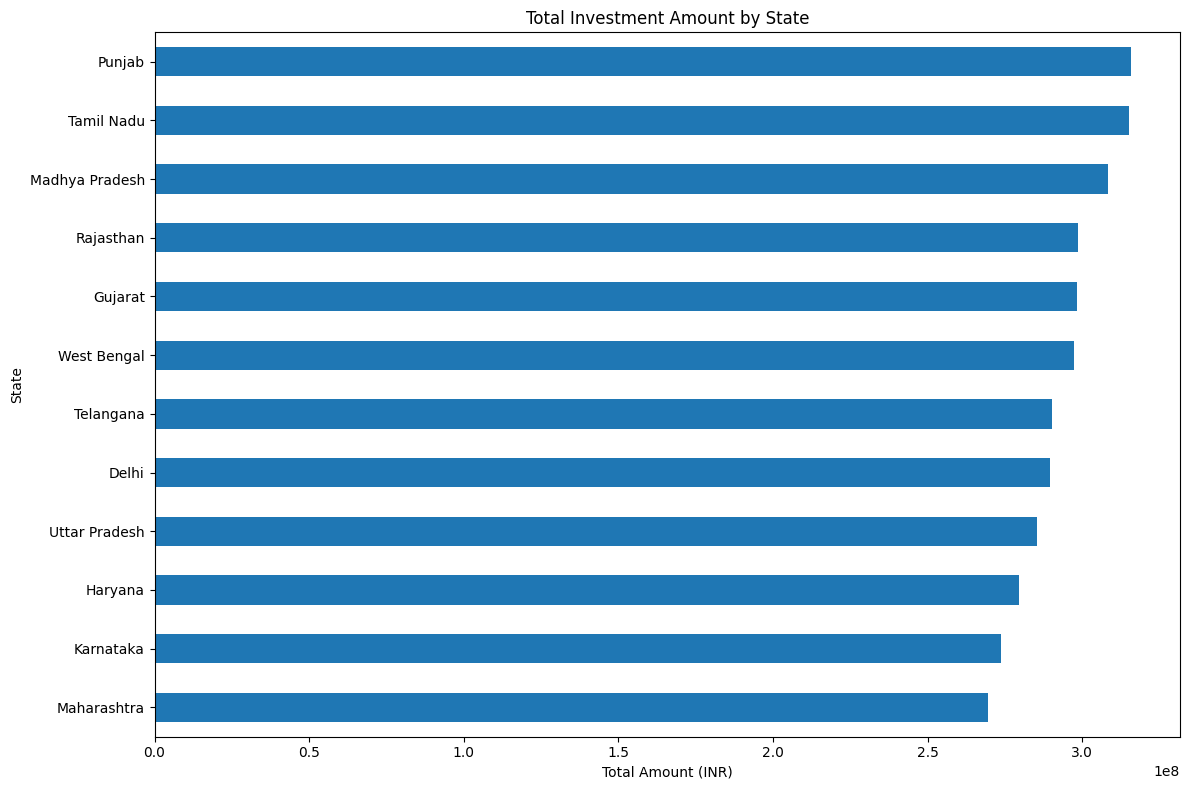

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import os

df = pd.read_csv("../data/processed/08_investor_transactions_cleaned.csv")

state_data = (
    df.groupby("state")["amount_inr"]
    .sum()
    .sort_values(ascending=True)
)

plt.figure(figsize=(12,8))

state_data.plot(kind="barh")

plt.title("Total Investment Amount by State")
plt.xlabel("Total Amount (INR)")
plt.ylabel("State")

plt.tight_layout()

os.makedirs("../reports/charts", exist_ok=True)
plt.savefig("../reports/charts/state_distribution.png")

plt.show()

## Insight 6: Geographic Distribution

Investment activity is concentrated in a few major states, indicating stronger mutual fund participation and awareness in those regions.

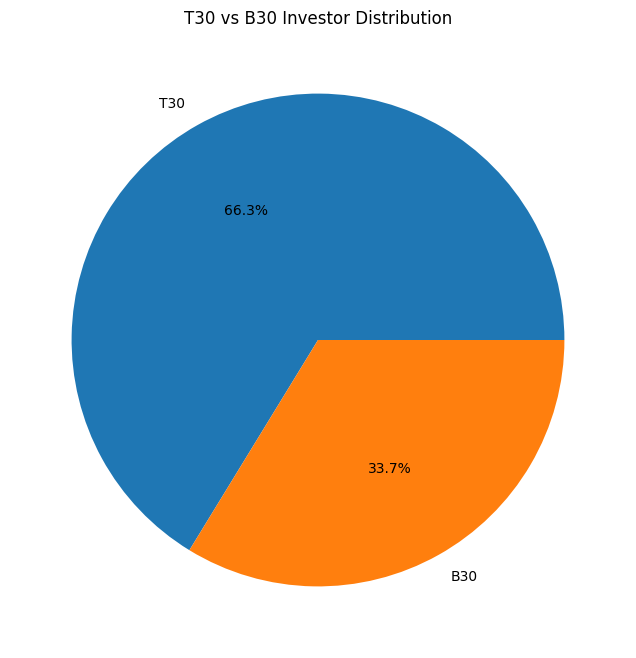

In [26]:
plt.figure(figsize=(8,8))

df["city_tier"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("T30 vs B30 Investor Distribution")
plt.ylabel("")

plt.savefig("../reports/charts/t30_b30_distribution.png")

plt.show()

## Insight 7: City Tier Analysis

While T30 cities contribute a significant share of investments, participation from B30 cities continues to grow, reflecting broader mutual fund adoption.

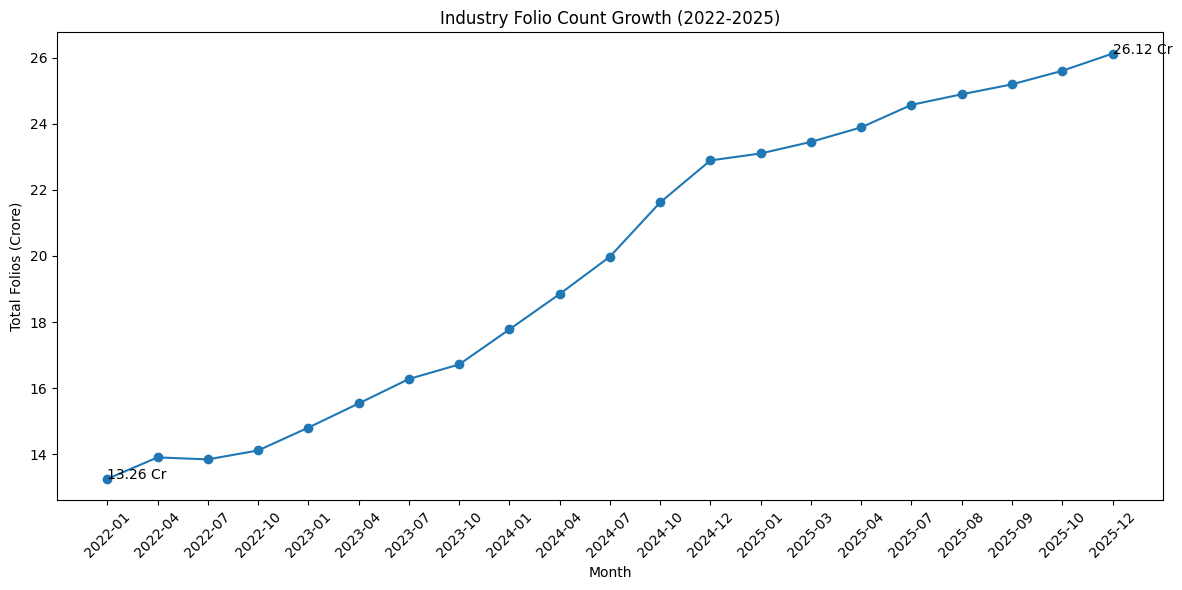

In [27]:
import pandas as pd
import matplotlib.pyplot as plt

folio = pd.read_csv("../data/raw/06_industry_folio_count.csv")

plt.figure(figsize=(12,6))

plt.plot(
    folio["month"],
    folio["total_folios_crore"],
    marker="o"
)

plt.title("Industry Folio Count Growth (2022-2025)")
plt.xlabel("Month")
plt.ylabel("Total Folios (Crore)")

plt.xticks(rotation=45)

# Mark start point
plt.annotate(
    "13.26 Cr",
    xy=(0, 13.26)
)

# Mark end point
plt.annotate(
    "26.12 Cr",
    xy=(len(folio)-1, 26.12)
)

plt.tight_layout()

plt.savefig("../reports/charts/folio_growth.png")

plt.show()

## Insight 8: Folio Growth

Total mutual fund folios nearly doubled during the analysis period, reflecting increasing retail investor participation.

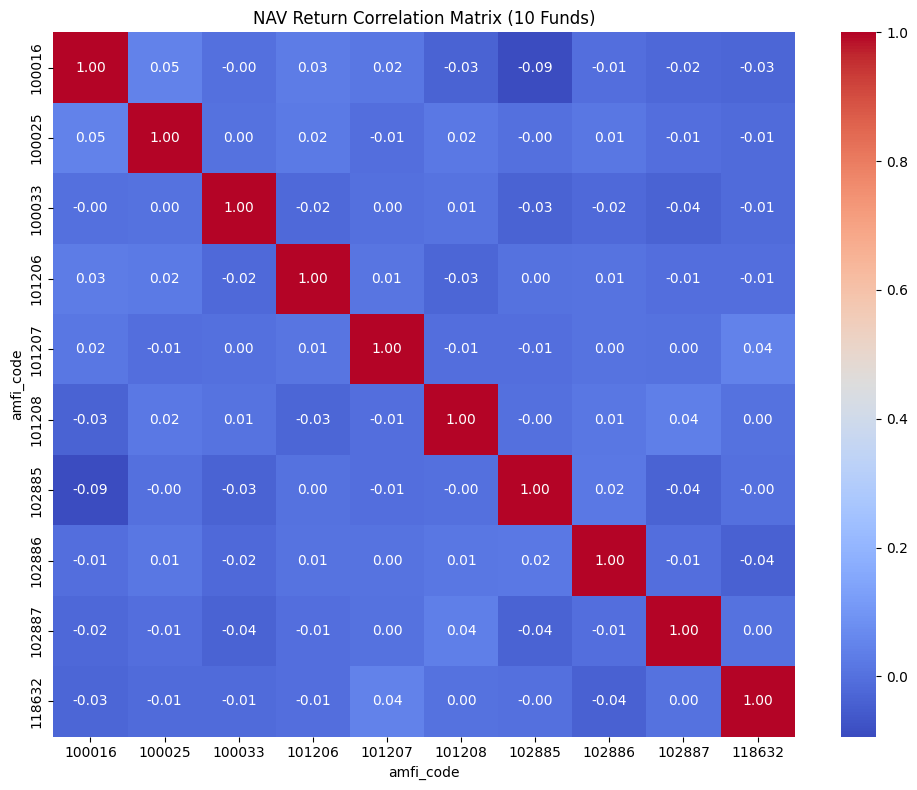

In [28]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

nav = pd.read_csv("../data/processed/02_nav_history_cleaned.csv")

nav["date"] = pd.to_datetime(nav["date"])

# Select first 10 funds
selected_funds = nav["amfi_code"].unique()[:10]

nav_10 = nav[nav["amfi_code"].isin(selected_funds)]

# Create pivot table
pivot_nav = nav_10.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)

# Daily returns
returns = pivot_nav.pct_change().dropna()

# Correlation matrix
corr_matrix = returns.corr()

# Plot heatmap
plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("NAV Return Correlation Matrix (10 Funds)")

plt.tight_layout()

plt.savefig("../reports/charts/nav_correlation_matrix.png")

plt.show()

## Insight 9: Fund Correlation Analysis

Most large-cap mutual funds exhibit strong positive correlations, indicating similar reactions to broader market movements.

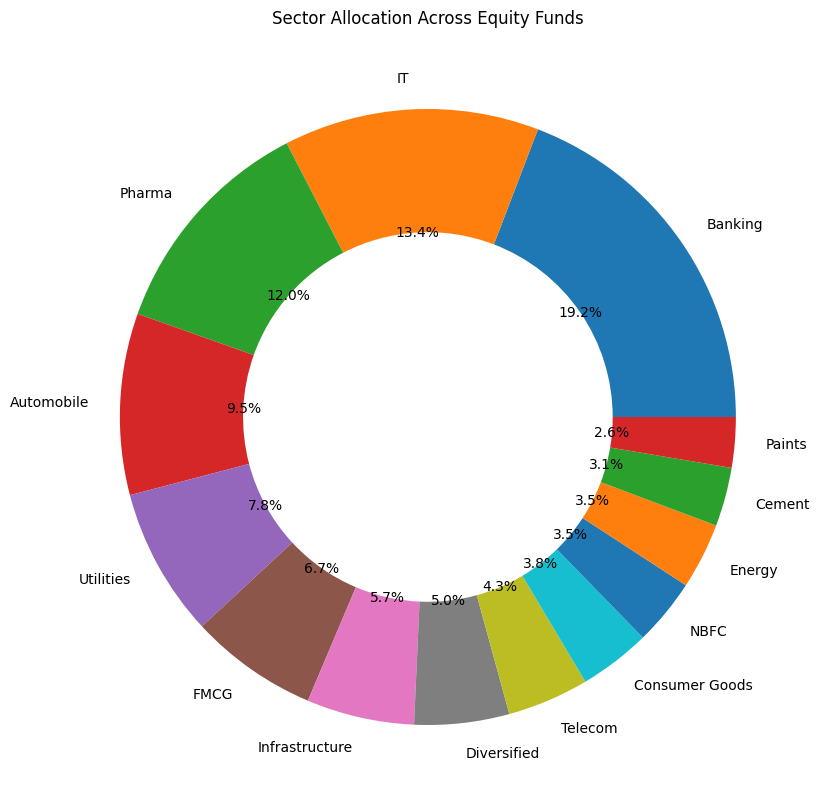

In [29]:
import pandas as pd
import matplotlib.pyplot as plt

holdings = pd.read_csv("../data/raw/09_portfolio_holdings.csv")

sector_data = (
    holdings.groupby("sector")["weight_pct"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,10))

plt.pie(
    sector_data,
    labels=sector_data.index,
    autopct="%1.1f%%",
    wedgeprops={"width":0.4}
)

plt.title("Sector Allocation Across Equity Funds")

plt.savefig("../reports/charts/sector_allocation_donut.png")

plt.show()

## Insight 10: Sector Allocation

Financial Services, Information Technology, and Consumer sectors account for a significant share of portfolio allocations across equity mutual funds.

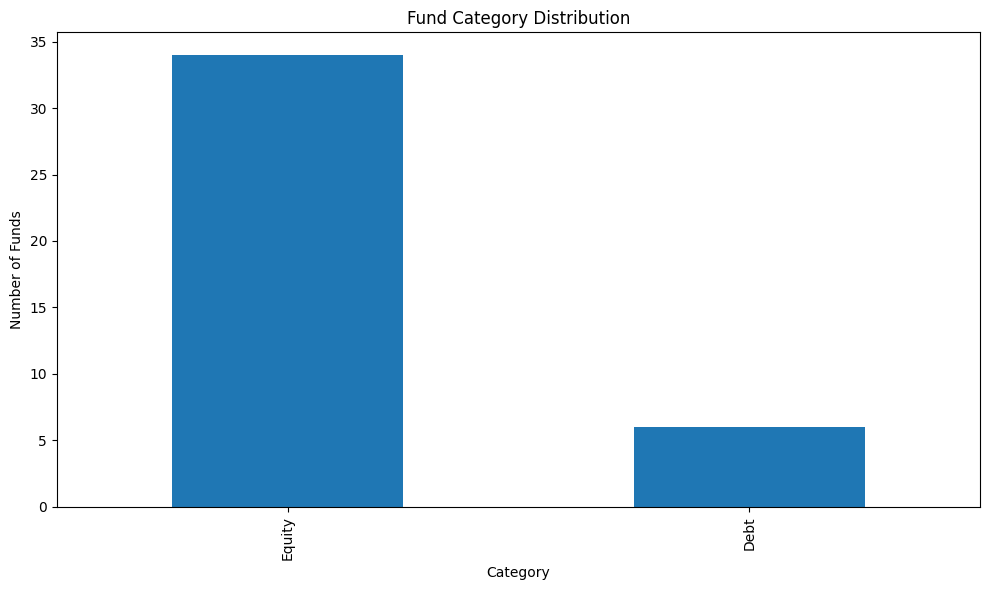

In [30]:
import pandas as pd
import matplotlib.pyplot as plt

funds = pd.read_csv("../data/raw/01_fund_master.csv")

plt.figure(figsize=(10,6))

funds["category"].value_counts().plot(
    kind="bar"
)

plt.title("Fund Category Distribution")
plt.xlabel("Category")
plt.ylabel("Number of Funds")

plt.tight_layout()

plt.savefig("../reports/charts/fund_category_distribution.png")

plt.show()

## Insight 11: Fund Category Distribution

Equity-oriented schemes dominate the mutual fund universe, reflecting investor preference for long-term wealth creation.

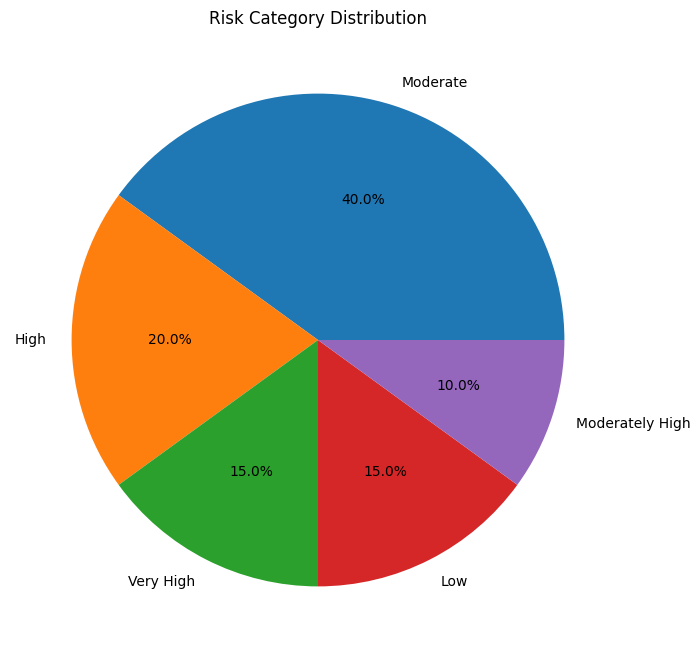

In [31]:
plt.figure(figsize=(8,8))

funds["risk_category"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Risk Category Distribution")
plt.ylabel("")

plt.savefig("../reports/charts/risk_category_distribution.png")

plt.show()

## Insight 12: Risk Profile Analysis

Most schemes fall under Moderate to Very High risk categories, highlighting the growth-oriented nature of mutual fund investments.

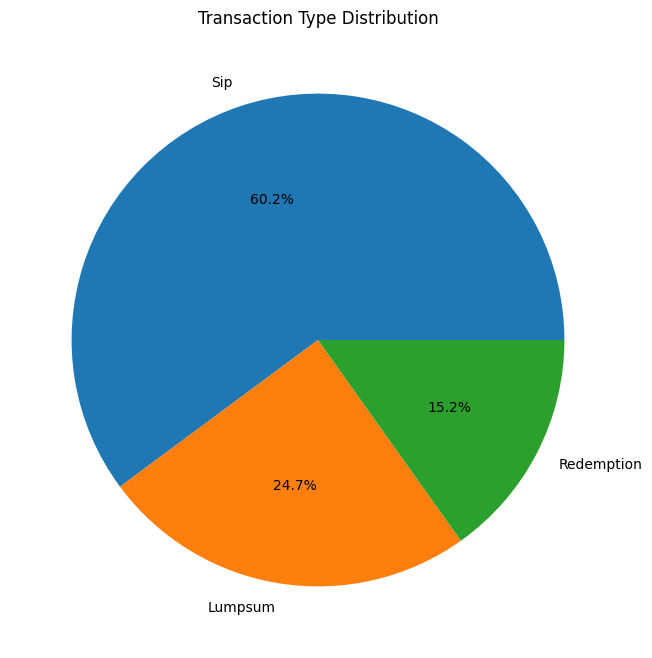

In [32]:
transactions = pd.read_csv(
    "../data/processed/08_investor_transactions_cleaned.csv"
)

plt.figure(figsize=(8,8))

transactions["transaction_type"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Transaction Type Distribution")
plt.ylabel("")

plt.savefig("../reports/charts/transaction_type_distribution.png")

plt.show()

## Insight 13: Transaction Behaviour

SIP transactions constitute a major portion of investor activity, demonstrating the popularity of disciplined periodic investing.